In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !find /content -type f -iname "*.jpg" -delete

In [ ]:
!tar -xzf /content/drive/MyDrive/rafdb.tar.gz -C /content/ #extraction

In [ ]:
!ls /content            # Lecture des fichiers à l'intérieur du dossier "rafdb.tar.gz"
!ls /content/archive
!ls /content/archive/RAF-DB
!ls /content/data
!ls /content
!ls /content/archive
!ls /content/archive/RAF-DB

archive  data  drive  get_dataset.py  sample_data
FER2013  RAF-DB
test  test_RAF_labels.csv  train  train_RAF_labels.csv
data
archive  data  drive  get_dataset.py  sample_data
FER2013  RAF-DB
test  test_RAF_labels.csv  train  train_RAF_labels.csv


In [27]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from matplotlib import pyplot as plt
from tqdm import tqdm

import pandas as pd
import numpy as np
from PIL import Image

import umap
import altair as alt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # mps GPU pour Mac
# device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class RAFDBDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.img_dir, self.labels.iloc[idx, 0])
        image = Image.open(img_name)
        label = self.labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from get_dataset import GiMeFiveDataset

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # transforms.RandomErasing(scale=(0.02,0.25)),
])

rafdb_dataset_train = GiMeFiveDataset(csv_file='/content/archive/RAF-DB/train_RAF_labels.csv',
                            img_dir='/content/archive/RAF-DB/train/',
                            transform=transform)

# rafdb_dataset_train = GiMeFiveDataset(csv_file='/content/archive/FER2013/train_FER_labels.csv',
#                             img_dir='/content/archive/FER2013/train/',
#                             transform=transform)

# rafdb_dataset_train = GiMeFiveDataset(csv_file='/content/data/train_labels.csv',
#                             img_dir='/content/data/train/',
#                             transform=transform)
data_train_loader = DataLoader(rafdb_dataset_train, batch_size=16, shuffle=True, num_workers=4)
train_image, train_label = next(iter(data_train_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

rafdb_dataset_vali = GiMeFiveDataset(csv_file='/content/data/data/valid_labels.csv', # modification du chemin
                            img_dir='/content/data/data/valid/',
                            transform=transform)

data_vali_loader = DataLoader(rafdb_dataset_vali, batch_size=16, shuffle=False, num_workers=0)
vali_image, vali_label = next(iter(data_vali_loader))
print(f"Vali batch: image shape {vali_image.shape}, labels shape {vali_label.shape}")

rafdb_dataset_test = GiMeFiveDataset(csv_file='/content/archive/RAF-DB/test_RAF_labels.csv',
                            img_dir='/content/archive/RAF-DB/test/',
                            transform=transform)

# rafdb_dataset_test = GiMeFiveDataset(csv_file='/content/archive/FER2013/test_FER_labels.csv',
#                             img_dir='/content/archive/FER2013/test/',
#                             transform=transform)

# rafdb_dataset_test = GiMeFiveDataset(csv_file='/content/data/test_labels.csv',
#                             img_dir='/content/data/test/',
#                             transform=transform)
data_test_loader = DataLoader(rafdb_dataset_test, batch_size=16, shuffle=False, num_workers=0)
test_image, test_label = next(iter(data_test_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Vali batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, hidden, bias=False)
        self.fc2 = nn.Linear(hidden, channels, bias=False)

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = F.relu(self.fc1(y), inplace=True)
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_se=False, dropout=0.2):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if use_se:
            layers.append(SEBlock(out_channels))
        layers.extend([
            nn.MaxPool2d(2),
            nn.Dropout(dropout)
        ])
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_se=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.use_se = use_se
        self.se = SEBlock(out_channels) if use_se else nn.Identity()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)

        out = out + identity
        out = F.relu(out, inplace=True)
        return out


class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, use_se=False, dropout=0.15),
            ConvBlock(64, 128, use_se=False, dropout=0.15),
            ConvBlock(128, 256, use_se=False, dropout=0.20),
            ConvBlock(256, 512, use_se=False, dropout=0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


class SECNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, use_se=True, dropout=0.15),
            ConvBlock(64, 128, use_se=True, dropout=0.15),
            ConvBlock(128, 256, use_se=True, dropout=0.20),
            ConvBlock(256, 512, use_se=True, dropout=0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


class ResNetSmall(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1, use_se=False),
            ResidualBlock(64, 64, stride=1, use_se=False),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, use_se=False),
            ResidualBlock(128, 128, stride=1, use_se=False),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, use_se=False),
            ResidualBlock(256, 256, stride=1, use_se=False),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2, use_se=False),
            ResidualBlock(512, 512, stride=1, use_se=False),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = F.max_pool2d(x, 2)   # 64 -> 32
        x = self.layer2(x)       # 32 -> 16
        x = self.layer3(x)       # 16 -> 8
        x = self.layer4(x)       # 8 -> 4
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


class SEResNetSmall(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1, use_se=True),
            ResidualBlock(64, 64, stride=1, use_se=True),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, use_se=True),
            ResidualBlock(128, 128, stride=1, use_se=True),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, use_se=True),
            ResidualBlock(256, 256, stride=1, use_se=True),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2, use_se=True),
            ResidualBlock(512, 512, stride=1, use_se=True),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = F.max_pool2d(x, 2)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


MODEL_FACTORY = {
    "baseline_cnn": BaselineCNN,
    "se_cnn": SECNN,
    "resnet_small": ResNetSmall,
    "se_resnet_small": SEResNetSmall,
}

In [ ]:
for model_name, model_class in MODEL_FACTORY.items():
    temp_model = model_class().to(device)
    total_params = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)
    print(f"{model_name}: {total_params} trainable parameters")

baseline_cnn: 1684806 trainable parameters
se_cnn: 1728838 trainable parameters
resnet_small: 11171910 trainable parameters
se_resnet_small: 11259974 trainable parameters


In [ ]:
# model.load_state_dict(torch.load('best_baseline.pth', map_location=device))
# model.eval()

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class BasicBlock(nn.Module):
#     expansion = 1

#     def __init__(self, in_planes, planes, stride=1):
#         super(BasicBlock, self).__init__()
#         self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(planes)
#         self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm2d(planes)

#         self.shortcut = nn.Sequential()
#         if stride != 1 or in_planes != self.expansion * planes:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
#                 nn.BatchNorm2d(self.expansion * planes)
#             )

#     def forward(self, x):
#         out = F.relu(self.bn1(self.conv1(x)))
#         out = self.bn2(self.conv2(out))
#         out += self.shortcut(x)
#         out = F.relu(out)
#         return out

# class ResNet(nn.Module):
#     def __init__(self, block, num_blocks, num_classes=6):
#         super(ResNet, self).__init__()
#         self.in_planes = 64

#         self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.bn1 = nn.BatchNorm2d(64)
#         self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
#         self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
#         self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
#         self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc = nn.Linear(512 * block.expansion, num_classes)

#     def _make_layer(self, block, planes, num_blocks, stride):
#         strides = [stride] + [1]*(num_blocks-1)
#         layers = []
#         for stride in strides:
#             layers.append(block(self.in_planes, planes, stride))
#             self.in_planes = planes * block.expansion
#         return nn.Sequential(*layers)

#     def forward(self, x):
#         out = F.relu(self.bn1(self.conv1(x)))
#         out = self.layer1(out)
#         out = self.layer2(out)
#         out = self.layer3(out)
#         out = self.layer4(out)
#         out = self.avgpool(out)
#         out = out.view(out.size(0), -1)
#         out = self.fc(out)
#         return out

# def EmotionClassifierResNet18():
#     return ResNet(BasicBlock, [2, 2, 2, 2])

# model = EmotionClassifierResNet18().to(device)


In [ ]:
# param_grid = {
#     'lr': [0.1, 0.01, 0.001, 0.0001],
#     'batch_size': [8, 16, 32, 64],
# }
# grid = ParameterGrid(param_grid)
# results = []

In [ ]:
# for params in grid: # Hyperparameter tuning
#     data_train_loader = DataLoader(rafdb_dataset_train, batch_size=params['batch_size'], shuffle=True, num_workers=4)
#     data_vali_loader = DataLoader(rafdb_dataset_vali, batch_size=params['batch_size'], shuffle=False, num_workers=0)

#     model = EmotionClassifier().to(device)
#     optimizer = optim.Adam(model.parameters(), lr=params['lr'])
#     criterion = nn.CrossEntropyLoss()

#     best_val_acc = 0
#     num_epochs = 15

#     for epoch in range(num_epochs):
#         model.train()
#         for i, data in enumerate(tqdm(data_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"), 0):
#             inputs, labels = data[0].to(device), data[1].to(device)
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#     model.eval()
#     val_correct = 0
#     val_total = 0
#     with torch.no_grad():
#         for data in data_vali_loader:
#             inputs, labels = data[0].to(device), data[1].to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs.data, 1)
#             val_total += labels.size(0)
#             val_correct += (predicted == labels).sum().item()

#     val_acc = val_correct / val_total
#     best_val_acc = max(best_val_acc, val_acc)

#     results.append({
#         'lr': params['lr'],
#         'batch_size': params['batch_size'],
#         'best_val_acc': best_val_acc,
#     })

# for result in results:
#     print(f"LR: {result['lr']}, Batch Size: {result['batch_size']}, Best Val Acc: {result['best_val_acc']}")

# best_params = max(results, key=lambda x: x['best_val_acc'])
# print(f"Best params: {best_params}")

In [ ]:
def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    avg_acc = correct / total
    return avg_loss, avg_acc

In [ ]:
def train_one_model(model_name, model_class, train_loader, val_loader, test_loader, num_epochs=40, patience=10):
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_val_acc = 0.0
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    print(f"\n========== Training {model_name} ==========")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"{model_name} | Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"{model_name} | Epoch {epoch+1:02d} | "
            f"lr={current_lr:.6f} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, f"best_{model_name}.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"{model_name}: no validation improvement for {patience_counter} epoch(s).")

        if patience_counter >= patience:
            print(f"Early stopping for {model_name}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val_loss, final_val_acc = evaluate_model(model, val_loader, criterion)
    final_test_loss, final_test_acc = evaluate_model(model, test_loader, criterion)

    result = {
        "model_name": model_name,
        "best_val_acc": best_val_acc,
        "final_val_acc": final_val_acc,
        "final_test_acc": final_test_acc,
        "final_val_loss": final_val_loss,
        "final_test_loss": final_test_loss,
        "num_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "history": history
    }

    return model, result


results = []
trained_models = {}

for model_name, model_class in MODEL_FACTORY.items():
    model, result = train_one_model(
        model_name=model_name,
        model_class=model_class,
        train_loader=data_train_loader,
        val_loader=data_vali_loader,
        test_loader=data_test_loader,
        num_epochs=40,
        patience=8
    )
    trained_models[model_name] = model
    results.append(result)


results_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Params": r["num_params"],
        "Best Val Acc": r["best_val_acc"],
        "Final Val Acc": r["final_val_acc"],
        "Final Test Acc": r["final_test_acc"],
        "Final Val Loss": r["final_val_loss"],
        "Final Test Loss": r["final_test_loss"],
    }
    for r in results
]).sort_values(by="Final Test Acc", ascending=False)

print(" Model de comparison :")
print(results_df)

results_df.to_csv("model_comparison_results.csv", index=False)


========== Training baseline_cnn ==========


baseline_cnn | Epoch 01 | lr=0.001000 | train_loss=1.4458 | train_acc=0.4880 | val_loss=1.8620 | val_acc=0.2020 | test_loss=1.3520 | test_acc=0.5002


baseline_cnn | Epoch 02 | lr=0.001000 | train_loss=1.3183 | train_acc=0.5222 | val_loss=1.8295 | val_acc=0.2204 | test_loss=1.2173 | test_acc=0.5689


baseline_cnn | Epoch 03 | lr=0.001000 | train_loss=1.1897 | train_acc=0.5789 | val_loss=1.6373 | val_acc=0.3673 | test_loss=1.1920 | test_acc=0.5773


baseline_cnn | Epoch 04 | lr=0.001000 | train_loss=1.1089 | train_acc=0.6382 | val_loss=1.5426 | val_acc=0.4140 | test_loss=0.9996 | test_acc=0.6887


...

se_resnet_small | Epoch 31 | lr=0.000125 | train_loss=0.2489 | train_acc=0.9990 | val_loss=1.1790 | val_acc=0.7078 | test_loss=0.7368 | test_acc=0.8509
se_resnet_small: no validation improvement for 4 epoch(s).


se_resnet_small | Epoch 32 | lr=0.000125 | train_loss=0.2481 | train_acc=0.9989 | val_loss=1.1632 | val_acc=0.7245 | test_loss=0.7262 | test_acc=0.8488
se_resnet_small: no validation improvement for 5 epoch(s).


se_resnet_small | Epoch 33 | lr=0.000125 | train_loss=0.2452 | train_acc=0.9998 | val_loss=1.1059 | val_acc=0.7362 | test_loss=0.7266 | test_acc=0.8530
se_resnet_small: no validation improvement for 6 epoch(s).


se_resnet_small | Epoch 34 | lr=0.000125 | train_loss=0.2446 | train_acc=1.0000 | val_loss=1.0994 | val_acc=0.7479 | test_loss=0.7234 | test_acc=0.8530
se_resnet_small: no validation improvement for 7 epoch(s).


se_resnet_small | Epoch 35 | lr=0.000063 | train_loss=0.2469 | train_acc=0.9998 | val_loss=1.1243 | val_acc=0.7362 | test_loss=0.7220 | test_acc=0.8542
se_resnet_small: no validation improvement for 8 epoch(s).
Early stopping for se_resnet_small.
 Model de comparison :
             Model    Params  Best Val Acc  Final Val Acc  Final Test Acc  \
2     resnet_small  11171910      0.766277       0.771285        0.850440   
0     baseline_cnn   1684806      0.711185       0.702838        0.849183   
3  se_resnet_small  11259974      0.752922       0.746244        0.842061   
1           se_cnn   1728838      0.676127       0.659432        0.811479   

   Final Val Loss  Final Test Loss  
2        0.967015         0.676090  
0        0.976411         0.654202  
3        1.056920         0.730569  
1        1.062139         0.700508  


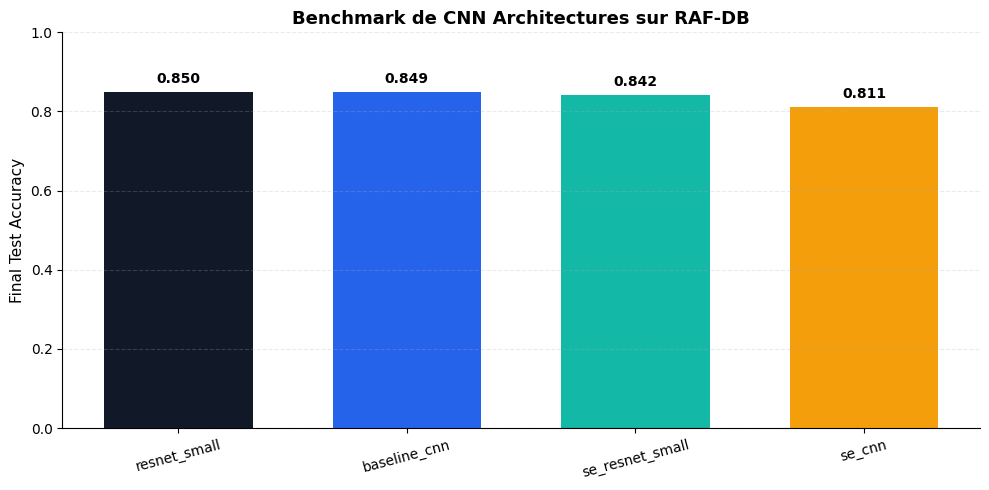

In [ ]:
plt.figure(figsize=(10, 5))

models = results_df["Model"]
scores = results_df["Final Test Acc"]
colors = ["#111827", "#2563EB", "#14B8A6", "#F59E0B"]
bars = plt.bar(models, scores, color=colors, width=0.65)

plt.ylabel("Final Test Accuracy", fontsize=11)
plt.title("Benchmark de CNN Architectures sur RAF-DB", fontsize=13, weight="bold")
plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )

plt.tight_layout()
plt.show()

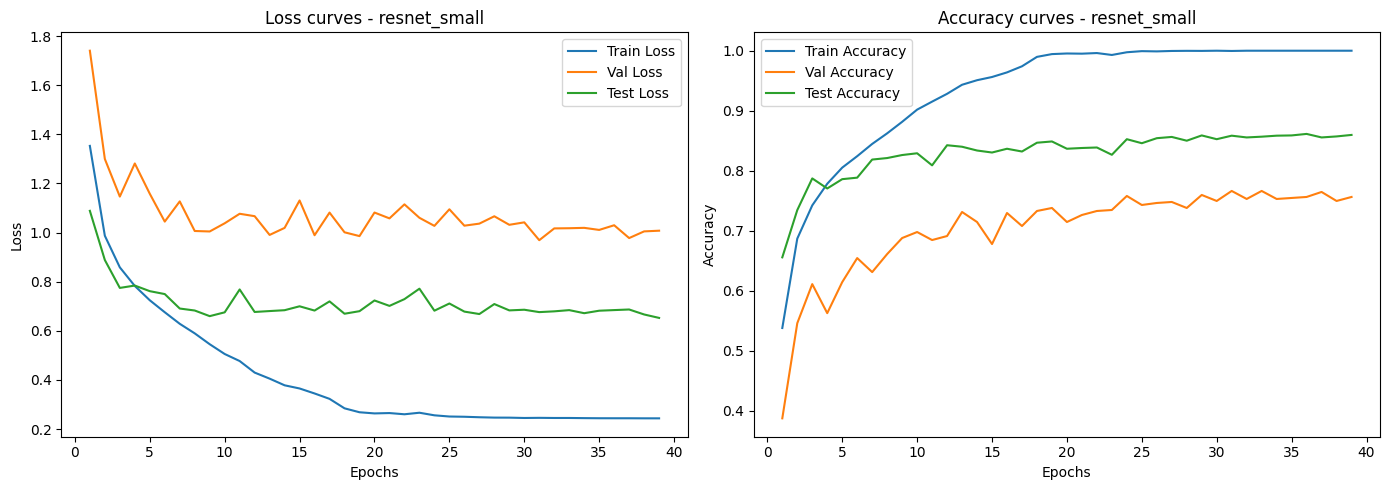

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_result = next(r for r in results if r["model_name"] == best_model_name)
history = best_result["history"]

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.plot(epochs, history["test_loss"], label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Loss curves - {best_model_name}")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.plot(epochs, history["test_acc"], label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Accuracy curves - {best_model_name}")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_model.eval()

print("Best model selected:", best_model_name)

Best model selected: resnet_small


In [29]:
### Création d'une fonction pour
# les vraies classes,
# les prédictions,
# les logits,
# les features profondes juste avant la dernière couche.



emotion_names = ["surprise", "fear", "disgust", "happy", "sad", "anger"]  # adapte si ton ordre diffère


def extract_features_and_predictions(model, loader, device):
    model.eval()

    all_features = []
    all_logits = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Cas CNN simples
            if hasattr(model, "features") and hasattr(model, "pool") and hasattr(model, "classifier"):
                x = model.features(inputs)
                x = model.pool(x)
                features = torch.flatten(x, 1)
                logits = model.classifier(features)

            # Cas ResNet-like
            elif hasattr(model, "stem") and hasattr(model, "layer1"):
                x = model.stem(inputs)
                x = model.layer1(x)
                x = F.max_pool2d(x, 2)
                x = model.layer2(x)
                x = model.layer3(x)
                x = model.layer4(x)
                x = model.pool(x)
                features = torch.flatten(x, 1)
                logits = model.fc(model.dropout(features))

            else:
                raise ValueError("Architecture non reconnue pour l'extraction des features.")

            preds = torch.argmax(logits, dim=1)

            all_features.append(features.cpu().numpy())
            all_logits.append(logits.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return {
        "features": np.vstack(all_features),
        "logits": np.vstack(all_logits),
        "preds": np.concatenate(all_preds),
        "labels": np.concatenate(all_labels)
    }


test_outputs = extract_features_and_predictions(best_model, data_test_loader, device)

X_features = test_outputs["features"]
X_logits = test_outputs["logits"]
y_true = test_outputs["labels"]
y_pred = test_outputs["preds"]

print("Features shape:", X_features.shape)
print("Logits shape:", X_logits.shape)
print("Test accuracy:", accuracy_score(y_true, y_pred))

Features shape: (2387, 512)
Logits shape: (2387, 6)
Test accuracy: 0.8579807289484709


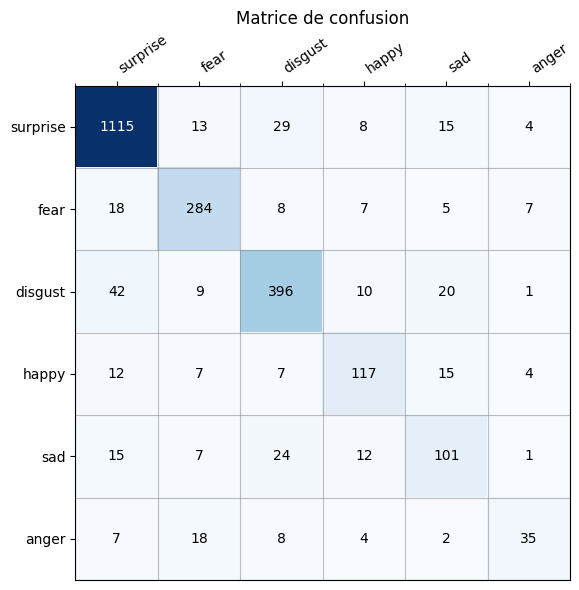

In [55]:
import matplotlib.pyplot as plt, numpy as np
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, names, title="Matrice de confusion"):       ### Matrice de confusion propre
    cm = confusion_matrix(y_true, y_pred, labels=range(len(names)))
    fig, ax = plt.subplots(figsize=(10,6)); ax.imshow(cm, cmap="Blues")

    ax.set(title=title); ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.xaxis.tick_top(); ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

    plt.setp(ax.get_xticklabels(), rotation=35, ha="left")
    th = cm.max()/2 if cm.max()>0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>th else "black")

    ax.set_xticks(np.arange(cm.shape[1]+1)-.5,minor=True); ax.set_yticks(np.arange(cm.shape[0]+1)-.5,minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.8, alpha=0.5); ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout(); plt.show()

plot_cm(y_true, y_pred, emotion_names)

In [31]:
print(classification_report(y_true, y_pred, target_names=emotion_names, digits=4))

              precision    recall  f1-score   support

    surprise     0.9222    0.9417    0.9319      1184
        fear     0.8402    0.8632    0.8516       329
     disgust     0.8390    0.8285    0.8337       478
       happy     0.7405    0.7222    0.7312       162
         sad     0.6392    0.6312    0.6352       160
       anger     0.6731    0.4730    0.5556        74

    accuracy                         0.8580      2387
   macro avg     0.7757    0.7433    0.7565      2387
weighted avg     0.8552    0.8580    0.8560      2387



In [32]:
pca_2d = PCA(n_components=2)                           ### Analyse PCA et de la variance expliquée
features_pca_2d = pca_2d.fit_transform(X_features)

explained_var_2 = pca_2d.explained_variance_ratio_
print("Explained variance ratio (2 PCA components):", explained_var_2)
print("Cumulative explained variance (2 components):", explained_var_2.sum())

Explained variance ratio (2 PCA components): [0.3347132  0.20933089]
Cumulative explained variance (2 components): 0.5440441


In [33]:
pca_95 = PCA(n_components=0.95)
features_pca_95 = pca_95.fit_transform(X_features)

print("Nombre de composantes pour conserver 95% de la variance :", pca_95.n_components_)

Nombre de composantes pour conserver 95% de la variance : 35


In [43]:
# pca_2D
df_pca = pd.DataFrame(features_pca_2d, columns=["x", "y"])
df_pca["true_label"] = [emotion_names[i] for i in y_true]
df_pca["pred_label"] = [emotion_names[i] for i in y_pred]

df_umap = pd.DataFrame(features_umap_2d, columns=["x", "y"])
df_umap["true_label"] = [emotion_names[i] for i in y_true]
df_umap["pred_label"] = [emotion_names[i] for i in y_pred]

In [38]:
# PCA et UMAP colorés par vraies classes
alt.data_transformers.disable_max_rows()

pca_chart_true = alt.Chart(df_pca).mark_circle(size=55).encode(
    x="x:Q",
    y="y:Q",
    color=alt.Color("true_label:N", title="True label"),
    tooltip=["true_label:N", "pred_label:N"]
).properties(
    width=380,
    height=380,
    title=f"PCA des features — vraies classes ({best_model_name})"
).interactive()

umap_chart_true = alt.Chart(df_umap).mark_circle(size=55).encode(
    x="x:Q",
    y="y:Q",
    color=alt.Color("true_label:N", title="True label"),
    tooltip=["true_label:N", "pred_label:N"]
).properties(
    width=380,
    height=380,
    title=f"UMAP des features — vraies classes ({best_model_name})"
).interactive()

pca_chart_true | umap_chart_true

alt.HConcatChart(...)

In [39]:
# PCA et UMAP par prédictions
pca_chart_pred = alt.Chart(df_pca).mark_circle(size=55).encode(
    x="x:Q",
    y="y:Q",
    color=alt.Color("pred_label:N", title="Predicted label"),
    tooltip=["true_label:N", "pred_label:N"]
).properties(
    width=380,
    height=380,
    title=f"PCA des features — classes prédites ({best_model_name})"
).interactive()

umap_chart_pred = alt.Chart(df_umap).mark_circle(size=55).encode(
    x="x:Q",
    y="y:Q",
    color=alt.Color("pred_label:N", title="Predicted label"),
    tooltip=["true_label:N", "pred_label:N"]
).properties(
    width=380,
    height=380,
    title=f"UMAP des features — classes prédites ({best_model_name})"
).interactive()

pca_chart_pred | umap_chart_pred

alt.HConcatChart(...)